# Combine Prophet and XGBoost for Demand Forecasting

Building a hybrid model that combines Prophet and XGBoost to forecast the daily sales of Rossmann stores. Prophet captures the trend and seasonality, while XGBoost corrects Prophet's errors using Promo, holiday, and store attributes.
The hybrid model is compared with Prophet and end-to-end XGBoost based on MAE, MAPE, and RMSPE. The main objective is to verify whether the added complexity justifies itself through the numbers.

-------------------------------------------------------------------------------------------------------------------------------------
Rossmann mağazalarının gündəlik satışını proqnozlaşdırmaq üçün Prophet və XGBoost-u birləşdirən hibrid model qurmaq. Prophet trend və mövsümiliyi tutur, XGBoost isə Prophet-in səhvlərini Promo, bayram və mağaza atributları ilə düzəldir.

Hibrid model Prophet və end-to-end XGBoost ilə MAE, MAPE və RMSPE üzrə müqayisə olunur. Əsas məqsəd əlavə mürəkkəbliyin rəqəmlərlə özünü doğrultub-doğrultmadığını yoxlamaqdır.

In [1]:
import pandas as pd

Rossmann Store Sales consists of 3 CSV files (store, train, test). However, we will work with only 2 of them. store.csv stores the fixed features of the store. XGBoost learns the differences between stores from this file. train.csv is the sales history. Prophet learns the time structure from this file. test.csv, on the other hand, represents the future period for the Kaggle competition, and its real sales are hidden. Therefore, we do not need it.

-------------------------------------------------------------------------------------------------------------------------------------
Rossmann Store Sales 3 csv fayl-dan ibarətdir (store, train, test). Biz isə sadəcə 2-i ilə işləyəcəyik. store.csv - mağazanın sabit xüsusiyyətlərini saxlayır. XGBoost mağazalar arasındakı fərqi bu fayldan öyrənir. train.csv - satış tarixçəsidir. Prophet zaman strukturunu bu fayldan öyrənir. test.csv isə Kaggle yarışması üçün gələcək dövrdür və real satışları gizlidir. Buna görə də bizə lazım deyil.

## "train.csv" file

In [2]:
train = pd.read_csv("train.csv", parse_dates=["Date"], low_memory=False)

- "parse_dates=["Date"]": The "Date" column is read as a datetime type rather than text (required for Prophet and calendar features).
- "low_memory=False": The file is read entirely at once to avoid type mismatch and "DtypeWarning" in columns with mixed types (e.g., "StateHoliday").

-------------------------------------------------------------------------------------------------------------------------------------
- "parse_dates=["Date"]": "Date" sütunu mətn kimi yox, datetime tipində oxunur (Prophet və təqvim feature-ləri üçün lazımdır).
- "low_memory=False": fayl bütövlükdə oxunur ki, qarışıq tipli sütunlarda (məsələn "StateHoliday") tip uyğunsuzluğu və "DtypeWarning" olmasın.

In [3]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[ns]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  object        
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[ns](1), int64(7), object(1)
memory usage: 69.8+ MB


In [5]:
train.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [6]:
train.duplicated().sum()

np.int64(0)

In [7]:
train["StateHoliday"].value_counts()

StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64

As noted in the "About this file" section: "StateHoliday – indicates a state holiday. Normally all stores, with few exceptions, are closed on state holidays. Note that all schools are closed on public holidays and weekends. a = public holiday, b = Easter holiday, c = Christmas, 0 = None". Based on the data description, the majority of stores are closed during holidays. Because XGBoost cannot handle text formats directly, the column was converted into four distinct 0/1 columns ("NoHoliday", "PublicHoliday", "EasterHoliday", "Christmas") via one-hot encoding.

-------------------------------------------------------------------------------------------------------------------------------------
Sənəddəki "Fayl haqqında" bölməsində belə qeyd edilib: "StateHoliday – dövlət bayramı günlərini göstərir. Azsaylı istisnaları çıxmaqla, rəsmi bayramlarda mağazaların hamısı bağlı olur. Həmçinin rəsmi bayram günlərində və həftəsonlarında bütün məktəblər də bağlıdır. a = rəsmi bayram, b = Pasxa bayramı, c = Milad bayramı, 0 = Heç biri". Məlumatların təsvirindən də göründüyü kimi, bayramlarda mağazaların böyük hissəsi fəaliyyət göstərmir. XGBoost alqoritmi mətn formatını birbaşa dəstəkləmədiyi üçün həmin sütun one-hot metodu ilə dörd fərqli 0 və 1-lərdən ibarət sütuna ("NoHoliday", "PublicHoliday", "EasterHoliday", "Christmas") çevrilmişdir.

In [8]:
train = pd.get_dummies(train, columns=["StateHoliday"], prefix="Holiday", dtype=int)

In [9]:
train = train.rename(columns={"Holiday_0": "NoHoliday", "Holiday_a": "PublicHoliday",
"Holiday_b": "EasterHoliday","Holiday_c": "Christmas",})

Because the data is in descending chronological order, starting with the latest date, we need to reverse it. Typically, during a train/validation split, the first (top) part is used for training and the last (bottom) part for validation. We must invert the order because we want the model to predict the future based on past data. If we don't, it will lead to data leakage.

-------------------------------------------------------------------------------------------------------------------------------------
Data da tarix azalan sırada olduğundan, yəni ən son tarixdən başladığından biz onu tərsinə çeviririk. Çünki, Train/validation bölgüsündə ilk (üst) hissə train, son (alt) hissə validation olur. Bizdə modeli keçmişə əsaslanaraq gələcəyi proqnozlaşdırmaq üçün edirik deyə tərs çevirməliyik. Əks halda, "leakage" olar.

In [10]:
train = train.sort_values("Date").reset_index(drop=True)

In [11]:
train = train.drop(columns=["Customers"])

We dropped the "Customers" column since this information won't be available for future dates. Keeping it would cause data leakage and give falsely optimistic validation scores.

-------------------------------------------------------------------------------------------------------------------------------------
"Customers" sütunu çıxarıldı: gələcək günlər üçün məlum olmadığından leakage yaradır və validation nəticələrini saxta yaxşılaşdırar.

In [12]:
train.head()

,Store,DayOfWeek,Date,Sales,Open,Promo,SchoolHoliday,NoHoliday,PublicHoliday,EasterHoliday,Christmas
0,1115,2,2013-01-01,0,0,0,1,0,1,0,0
1,379,2,2013-01-01,0,0,0,1,0,1,0,0
2,378,2,2013-01-01,0,0,0,1,0,1,0,0
3,377,2,2013-01-01,0,0,0,1,0,1,0,0
4,376,2,2013-01-01,0,0,0,1,0,1,0,0


## "store.csv" file

In [13]:
store = pd.read_csv("store.csv")

In [14]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [15]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [16]:
store.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [17]:
store.duplicated().sum()

np.int64(0)

The task strictly utilizes "StoreType", "Assortment", "CompetitionDistance", and "Promo2". The other five columns were dropped:

- "Promo2SinceWeek", "Promo2SinceYear", "PromoInterval" (544 blanks): These columns are blank because stores where "Promo2 = 0" are not part of the promotion. This shouldn't be treated as missing data, as the "Promo2" column already captures their participation.
- "CompetitionOpenSinceMonth", "CompetitionOpenSinceYear" (354 blanks): The competitor's opening date is missing. Since we already have the competitor's distance ("CompetitionDistance"), the exact date is unnecessary for this task.

-------------------------------------------------------------------------------------------------------------------------------------
Tapşırıqda yalnız "StoreType", "Assortment", "CompetitionDistance" və "Promo2" istifadə olunur. Qalan beş sütun çıxarıldı:

- "Promo2SinceWeek", "Promo2SinceYear", "PromoInterval" (544 boşluq): "Promo2 = 0" olan mağazalar proqramda iştirak etmir, ona görə bu sütunlar boşdur. Bu itkin məlumat deyil. "Promo2" sütunu artıq iştirak məlumatını verir.
- "CompetitionOpenSinceMonth", "CompetitionOpenSinceYear" (354 boşluq): rəqibin açılış tarixi qeyd olunmayıb. Rəqibin məsafəsi ("CompetitionDistance") məlum olduğu üçün tarix bu tapşırıqda lazım deyil.

In [18]:
store = store.drop(columns=["Promo2SinceWeek", "Promo2SinceYear", "PromoInterval","CompetitionOpenSinceMonth",
"CompetitionOpenSinceYear",])

In [19]:
store[store["CompetitionDistance"].isnull()]

,Store,StoreType,Assortment,CompetitionDistance,Promo2
290,291,d,a,NaN,0
621,622,a,c,NaN,0
878,879,d,a,NaN,1


In [20]:
store["CompetitionDistance"] = store["CompetitionDistance"].fillna(store["CompetitionDistance"].median())

CompetitionDistance was missing for 3 stores (291, 622, 879). It was filled with the median because the median is not affected by extreme values. Only 3 of 1115 stores are affected, so the impact is negligible.

-------------------------------------------------------------------------------------------------------------------------------------
CompetitionDistance 3 mağazada (291, 622, 879) yoxdur. Median kənar dəyərlərdən təsirlənmədiyi üçün onunla dolduruldu. Bu, 1115 mağazadan yalnız 3-nə aiddir, təsiri cüzidir.

In [21]:
store = pd.get_dummies(store, columns=["StoreType", "Assortment"], dtype=int)

Because "StoreType" and "Assortment" are text-based, we converted them into 0/1 columns via one-hot encoding (XGBoost cannot handle text directly).

-------------------------------------------------------------------------------------------------------------------------------------
"StoreType" və "Assortment" mətn olduğu üçün one-hot ilə 0/1 sütunlara çevrildi (XGBoost mətn qəbul etmir).

In [22]:
#Assortment - describes an assortment level: a = basic, b = extra, c = extended
store = store.rename(columns={"Assortment_a": "Assortment_basic", "Assortment_b": "Assortment_extra",
"Assortment_c": "Assortment_extended"})

In [23]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Store                1115 non-null   int64  
 1   CompetitionDistance  1115 non-null   float64
 2   Promo2               1115 non-null   int64  
 3   StoreType_a          1115 non-null   int64  
 4   StoreType_b          1115 non-null   int64  
 5   StoreType_c          1115 non-null   int64  
 6   StoreType_d          1115 non-null   int64  
 7   Assortment_basic     1115 non-null   int64  
 8   Assortment_extra     1115 non-null   int64  
 9   Assortment_extended  1115 non-null   int64  
dtypes: float64(1), int64(9)
memory usage: 87.2 KB


## Merge

In [24]:
df = train.merge(store, on="Store", how="left", validate="many_to_one")

- Merged "train" (daily sales) and "store" (store attributes) based on the "Store" column.
- how="left": Keeps all rows from "train" and attaches the respective store details to each one.
- validate="many_to_one": The store ID appears many times in "train" (daily records) but is unique in "store" (one row per store), resulting in a many-to-one relationship.
- If duplicates existed in "store", it would cause a silent row explosion; this validation rule catches that and throws an error.

-------------------------------------------------------------------------------------------------------------------------------------
- "train" (gündəlik satışlar) və "store" (mağaza xüsusiyyətləri) "Store" sütunu üzrə birləşdirildi.
- 'how="left"': "train"-in bütün sətirləri saxlanılır, hər sətrə öz mağazasının xüsusiyyətləri əlavə olunur.
- 'validate="many_to_one"': "train"-də mağaza çox təkrarlanır (hər gün bir sətir), "store"-da isə hər mağaza bir dəfə yazılıb. Yəni - "çoxdan birə" bağlantı gözləyirik.
- "store"-da təkrar olsaydı, sətirlər səssizcə çoxalardı, bu qayda buna xəta verir.

In [25]:
df.head()

,Store,DayOfWeek,Date,Sales,Open,Promo,SchoolHoliday,NoHoliday,PublicHoliday,EasterHoliday,Christmas,CompetitionDistance,Promo2,StoreType_a,StoreType_b,StoreType_c,StoreType_d,Assortment_basic,Assortment_extra,Assortment_extended
0,1115,2,2013-01-01,0,0,0,1,0,1,0,0,5350.0,1,0,0,0,1,0,0,1
1,379,2,2013-01-01,0,0,0,1,0,1,0,0,6630.0,0,0,0,0,1,1,0,0
2,378,2,2013-01-01,0,0,0,1,0,1,0,0,2140.0,0,1,0,0,0,0,0,1
3,377,2,2013-01-01,0,0,0,1,0,1,0,0,100.0,1,1,0,0,0,0,0,1
4,376,2,2013-01-01,0,0,0,1,0,1,0,0,160.0,0,1,0,0,0,1,0,0


In [26]:
df.shape

(1017209, 20)

In [27]:
df.isnull().sum()

Store                  0
DayOfWeek              0
Date                   0
Sales                  0
Open                   0
Promo                  0
SchoolHoliday          0
NoHoliday              0
PublicHoliday          0
EasterHoliday          0
Christmas              0
CompetitionDistance    0
Promo2                 0
StoreType_a            0
StoreType_b            0
StoreType_c            0
StoreType_d            0
Assortment_basic       0
Assortment_extra       0
Assortment_extended    0
dtype: int64

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
(df["Sales"] == 0).sum()
print("Number of days with 0 sales:",(df["Sales"] == 0).sum())

Number of days with 0 sales: 172871


In [30]:
(df["Open"] == 0).sum()
print("Number of days the store is closed:",(df["Open"] == 0).sum())

Number of days the store is closed: 172817


In [31]:
((df["Sales"] == 0) & (df["Open"] == 1)).sum()
print("Open but no sales days:",((df["Sales"] == 0) & (df["Open"] == 1)).sum())

Open but no sales days: 54


Most zero-sales days coincide with store closures (172,871 zero-sales rows vs 172,817 closed rows). Only 54 rows are open with zero sales; these were not examined individually.

-------------------------------------------------------------------------------------------------------------------------------------
Sıfır satışlı günlərin demək olar ki, hamısı mağazanın bağlı olduğu günlərə uyğun gəlir (172 871 sıfır satış, 172 817 bağlı gün). Yalnız 54 sətirdə mağaza açıqdır, amma satış yoxdur. Bu günlərə ayrıca baxılmayıb.

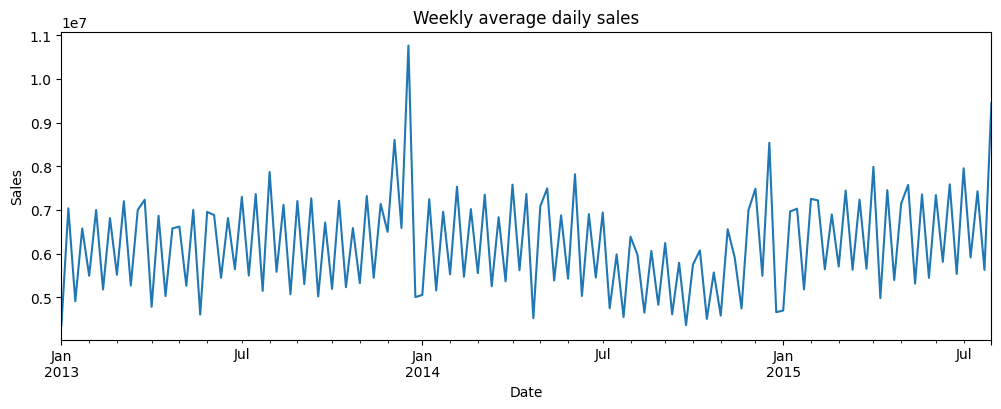

In [32]:
import matplotlib.pyplot as plt

# Graph 1.
weekly = df.groupby("Date")["Sales"].sum().resample("W").mean()
weekly.plot(figsize=(12, 4), title="Weekly average daily sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

Weekly average sales fluctuate between roughly 5 and 7 million with no clear upward or downward trend. There is a peak every December and a dip in the second half of 2014. This is the structure Prophet's trend and yearly seasonality will try to capture.

-------------------------------------------------------------------------------------------------------------------------------------
Həftəlik orta satış təxminən 5-7 milyon arasında dəyişir, aydın artım və ya azalma trendi yoxdur. Hər dekabrda zirvə, 2014-ün ikinci yarısında isə enmə var. Prophet-in trend və illik mövsümilik hissəsi bunu tutmağa çalışacaq.

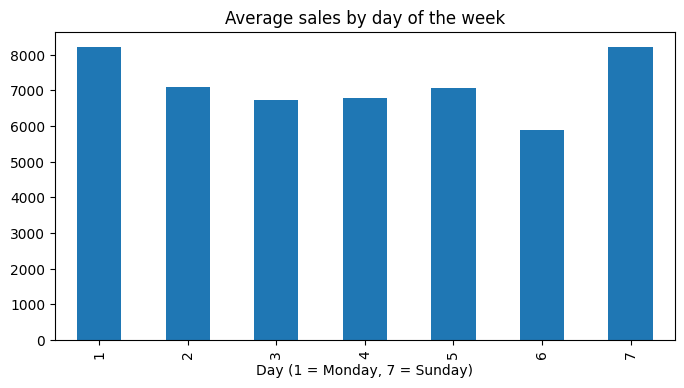

In [33]:
# Graph 2.
open_df = df[df["Open"] == 1]

open_df.groupby("DayOfWeek")["Sales"].mean().plot(kind="bar", figsize=(8, 4), title="Average sales by day of the week")
plt.xlabel("Day (1 = Monday, 7 = Sunday)")
plt.show()

This shows the average sales of one open store. Sunday looks high only because the few stores that open on Sundays are strong ones.

-------------------------------------------------------------------------------------------------------------------------------------
Bu qrafik açıq olan bir mağazanın orta satışını göstərir. Bazar günü yüksək görünür, çünki həmin gün açıq qalan az sayda mağaza güclü mağazalardır.

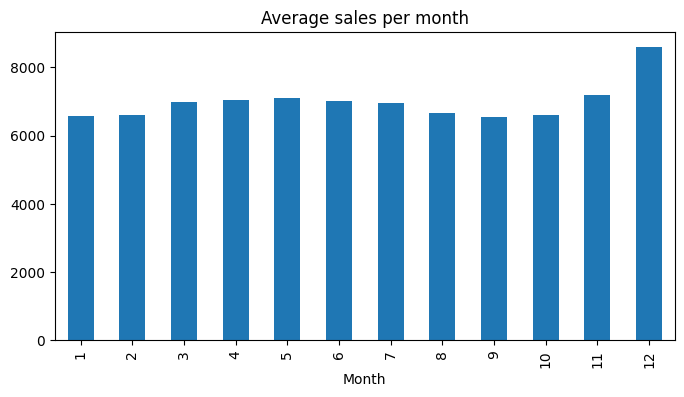

In [34]:
# Graph 3.
open_df.groupby(open_df["Date"].dt.month)["Sales"].mean().plot(kind="bar", figsize=(8, 4), title="Average sales per month")
plt.xlabel("Month")
plt.show()

Sales are highest in December (about 8,600) and fairly flat in the other months. Note that January-July include three years of data while August-December include only two.

-------------------------------------------------------------------------------------------------------------------------------------
Satış dekabrda ən yüksəkdir (təxminən 8 600), digər aylarda nisbətən sabitdir. Qeyd: yanvar-iyul aylarına üç il, avqust-dekabr aylarına iki il daxildir.

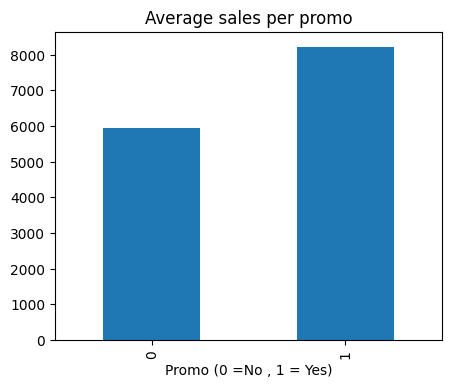

In [35]:
# Graph 4.
open_df.groupby("Promo")["Sales"].mean().plot(kind="bar", figsize=(5, 4), title="Average sales per promo")
plt.xlabel("Promo (0 =No , 1 = Yes)")
plt.show()

On promo days the average sales of an open store are about 38% higher (about 8,200 vs 5,900). Promo is therefore a useful regressor for XGBoost.

-------------------------------------------------------------------------------------------------------------------------------------
Aksiya günlərində açıq mağazanın orta satışı təxminən 38% yüksəkdir (təxminən 8 200 qarşı 5 900). Buna görə Promo XGBoost üçün faydalı regressordur.

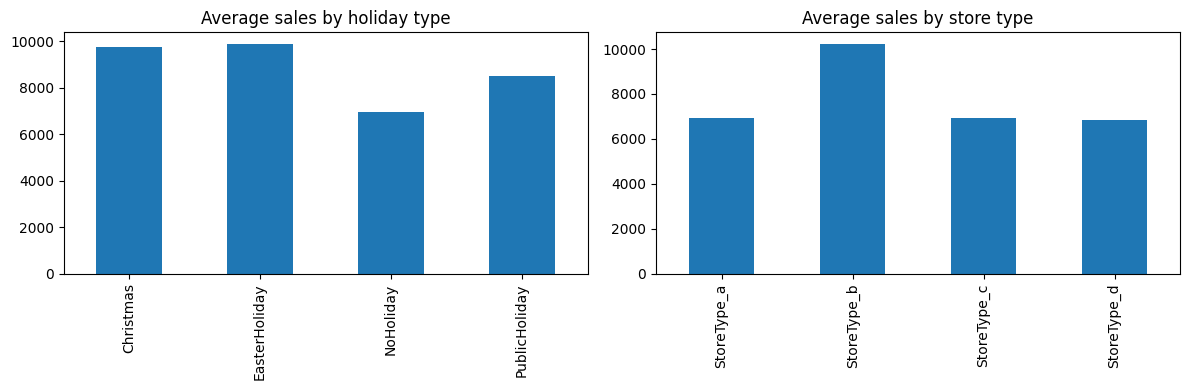

In [36]:
# Graph 5.
holiday = open_df[["NoHoliday", "PublicHoliday", "EasterHoliday", "Christmas"]].idxmax(axis=1)
store_type = open_df[["StoreType_a", "StoreType_b", "StoreType_c", "StoreType_d"]].idxmax(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
open_df.groupby(holiday)["Sales"].mean().plot(kind="bar", ax=axes[0], title="Average sales by holiday type")
open_df.groupby(store_type)["Sales"].mean().plot(kind="bar", ax=axes[1], title="Average sales by store type")
plt.tight_layout()
plt.show()

Open stores sell more on holidays than on normal days, and store type b sells clearly more than the others. Holiday groups are based on few rows because most stores are closed on holidays. These factors are what XGBoost can learn and Prophet cannot.

-------------------------------------------------------------------------------------------------------------------------------------
Açıq mağazalar bayram günlərində adi günlərdən çox satır, b tipli mağazalar isə digərlərindən açıq-aydın yüksəkdir. Bayram qrupları az sətrə əsaslanır, çünki bayramda mağazaların çoxu bağlıdır. XGBoost-un öyrənə biləcəyi, Prophet-in isə bilmədiyi amillər bunlardır.

In [37]:
daily = df.groupby("Date")["Sales"].sum().reset_index()
daily.head()

,Date,Sales
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593


As the stores belong to the same chain (Rossmann), sales are consolidated daily to forecast the chain's total daily sales

-------------------------------------------------------------------------------------------------------------------------------------
Mağazalar eyni şəbəkənin (rossmann) filialları olduğu üçün satış, gün üzrə cəmlənir və şəbəkənin ümumi gündəlik satışı proqnozlaşdırılır.

In [38]:
daily = df.groupby("Date").agg(Sales=("Sales", "sum"), Open=("Open", "sum"), Promo=("Promo", "mean"),
SchoolHoliday=("SchoolHoliday", "mean"), PublicHoliday=("PublicHoliday", "mean"),EasterHoliday=("EasterHoliday", "mean"),
Christmas=("Christmas", "mean"),).reset_index()

daily.head()

,Date,Sales,Open,Promo,SchoolHoliday,PublicHoliday,EasterHoliday,Christmas
0,2013-01-01,97235,17,0.0,1.000000,1.0,0.0,0.0
1,2013-01-02,6949829,1111,0.0,1.000000,0.0,0.0,0.0
2,2013-01-03,6347820,1109,0.0,0.932735,0.0,0.0,0.0
3,2013-01-04,6638954,1108,0.0,0.932735,0.0,0.0,0.0
4,2013-01-05,5951593,1107,0.0,0.100448,0.0,0.0,0.0


In [39]:
daily.shape

(942, 8)

Once sales are grouped by date, the remaining columns are included. Here, 'sales' and 'open' (store open status) are aggregated using 'sum'. Normally, 'open' indicates whether a store is open or not. However, since we need the total count of open stores, we applied 'sum'. The rest are aggregated using 'mean' as they represent binary (0/1) values.

-------------------------------------------------------------------------------------------------------------------------------------
Satışları tarixə görə müəyyənləşdirdikdən sonra, qalan digər sütunlarıda daxil edirik. Burada, sales(satış) və open( mağazaların açıq olub-olmadığı)  - "sum". Normalda, "open" bizə mağazaların açıq olub-olmadığını göstərir. Lakin bizə say olaraq nə qədər mağazanın açıq olub-olmadığı lazımdır deyə, "sum" tətbiq edildi. Digərləri isə nəticə olaraq bəli/xeyr (0/1) ifadə etdiyi üçün - "mean".

In [40]:
open_df = df[df["Open"] == 1]

store_cols = ["CompetitionDistance", "Promo2", "StoreType_a", "StoreType_b", "StoreType_c", "StoreType_d",
"Assortment_basic", "Assortment_extra", "Assortment_extended"]

store_daily = open_df.groupby("Date")[store_cols].mean().reset_index()
daily = daily.merge(store_daily, on="Date", how="left")

Store attributes ('StoreType', 'Assortment', 'CompetitionDistance', 'Promo2') were aggregated to a daily level. By filtering for stores open on that day (open == 1), the values were averaged chronologically to reflect the composition of active stores.

-------------------------------------------------------------------------------------------------------------------------------------
Mağaza atributları ("StoreType", "Assortment", "CompetitionDistance", "Promo2") gün səviyyəsinə gətirildi. Yalnız həmin gün açıq (open == 1) olan mağazalar götürülüb, tarix üzrə ortalanıb (açıq mağazaların tərkibi kimi).

In [41]:
daily.head()

,Date,Sales,Open,Promo,SchoolHoliday,PublicHoliday,EasterHoliday,Christmas,CompetitionDistance,Promo2,StoreType_a,StoreType_b,StoreType_c,StoreType_d,Assortment_basic,Assortment_extra,Assortment_extended
0,2013-01-01,97235,17,0.0,1.000000,1.0,0.0,0.0,2105.294118,0.294118,0.058824,0.941176,0.000000,0.000000,0.352941,0.529412,0.117647
1,2013-01-02,6949829,1111,0.0,1.000000,0.0,0.0,0.0,5408.501350,0.513051,0.541854,0.014401,0.132313,0.311431,0.532853,0.008101,0.459046
2,2013-01-03,6347820,1109,0.0,0.932735,0.0,0.0,0.0,5414.477006,0.513075,0.541930,0.014427,0.131650,0.311993,0.533814,0.008115,0.458070
3,2013-01-04,6638954,1108,0.0,0.932735,0.0,0.0,0.0,5418.831227,0.512635,0.542419,0.013538,0.131769,0.312274,0.534296,0.007220,0.458484
4,2013-01-05,5951593,1107,0.0,0.100448,0.0,0.0,0.0,5403.410117,0.513098,0.542005,0.013550,0.131888,0.312556,0.534779,0.007227,0.457995


In [42]:
daily.shape

(942, 17)

In [43]:
daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 942 entries, 0 to 941
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 942 non-null    datetime64[ns]
 1   Sales                942 non-null    int64         
 2   Open                 942 non-null    int64         
 3   Promo                942 non-null    float64       
 4   SchoolHoliday        942 non-null    float64       
 5   PublicHoliday        942 non-null    float64       
 6   EasterHoliday        942 non-null    float64       
 7   Christmas            942 non-null    float64       
 8   CompetitionDistance  942 non-null    float64       
 9   Promo2               942 non-null    float64       
 10  StoreType_a          942 non-null    float64       
 11  StoreType_b          942 non-null    float64       
 12  StoreType_c          942 non-null    float64       
 13  StoreType_d          942 non-null  

In [44]:
daily.isnull().sum().sum()

np.int64(0)

In [45]:
daily.duplicated().sum()

np.int64(0)

In [46]:
daily.describe()

,Date,Sales,Open,Promo,SchoolHoliday,PublicHoliday,EasterHoliday,Christmas,CompetitionDistance,Promo2,StoreType_a,StoreType_b,StoreType_c,StoreType_d,Assortment_basic,Assortment_extra,Assortment_extended
count,942,9.420000e+02,942.000000,942.000000,942.000000,942.000000,942.000000,942.000000,942.000000,942.000000,942.000000,942.000000,942.000000,942.000000,942.000000,942.000000,942.000000
mean,2014-04-16 12:00:00,6.234799e+06,896.382166,0.382166,0.181645,0.019579,0.006369,0.004246,6036.337189,0.461372,0.495380,0.125723,0.112371,0.266525,0.490110,0.066436,0.443454
min,2013-01-01 00:00:00,9.723500e+04,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1060.588235,0.235294,0.000000,0.012624,0.000000,0.000000,0.212121,0.006312,0.055556
25%,2013-08-24 06:00:00,5.675832e+06,934.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5396.614350,0.443760,0.539497,0.015247,0.131957,0.285561,0.511230,0.008072,0.460018
50%,2014-04-16 12:00:00,6.580354e+06,1111.000000,0.000000,0.019731,0.000000,0.000000,0.000000,5400.466786,0.512108,0.539910,0.015274,0.132735,0.312108,0.531418,0.008094,0.460432
75%,2014-12-07 18:00:00,8.174899e+06,1114.000000,1.000000,0.228251,0.000000,0.000000,0.000000,5540.399053,0.512173,0.541028,0.017131,0.132974,0.312388,0.531839,0.008572,0.468750
max,2015-07-31 00:00:00,1.562355e+07,1115.000000,1.000000,1.000000,1.000000,1.000000,1.000000,14225.483871,0.525000,0.564103,1.000000,0.195804,0.320715,0.535747,0.562500,0.516129
std,NaN,3.130536e+06,398.873635,0.486175,0.294914,0.129434,0.079596,0.065060,2536.714432,0.085467,0.124448,0.258541,0.050587,0.091671,0.088785,0.136692,0.086168


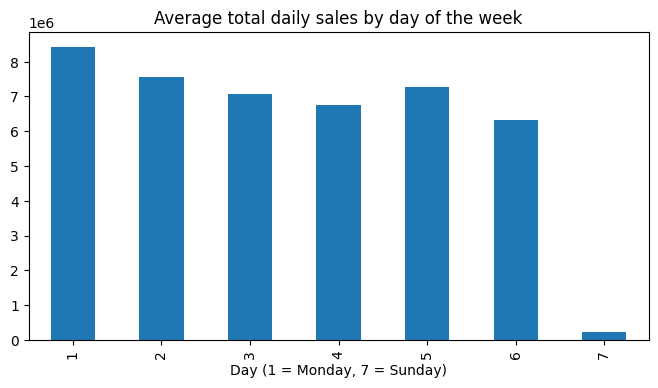

          Sales    Open
Date                   
1     8434351.0  1027.0
2     7558607.0  1066.0
3     7073799.0  1051.0
4     6749465.0   997.0
5     7263377.0  1027.0
6     6315804.0  1075.0
7      220533.0    27.0


In [47]:
# Graph 6.
dow = daily["Date"].dt.dayofweek + 1

daily.groupby(dow)["Sales"].mean().plot(kind="bar", figsize=(8, 4), title="Average total daily sales by day of the week")
plt.xlabel("Day (1 = Monday, 7 = Sunday)")
plt.show()

print(daily.groupby(dow)[["Sales", "Open"]].mean().round(0))

The chain's total sales are highest on Monday (about 8.4 million), lowest among working days on Saturday (about 6.3 million) and almost zero on Sunday (about 0.22 million) because only about 27 stores are open. There is strong weekly seasonality, which Prophet's weekly component should capture.

-------------------------------------------------------------------------------------------------------------------------------------
Şəbəkənin ümumi satışı bazar ertəsi ən yüksəkdir (təxminən 8,4 mln), iş günləri arasında şənbə ən aşağıdır (təxminən 6,3 mln), bazar günü isə demək olar ki, sıfırdır (təxminən 0,22 mln), çünki cəmi təxminən 27 mağaza açıqdır. Güclü həftəlik mövsümilik var, Prophet-in həftəlik komponenti bunu tutmalıdır.

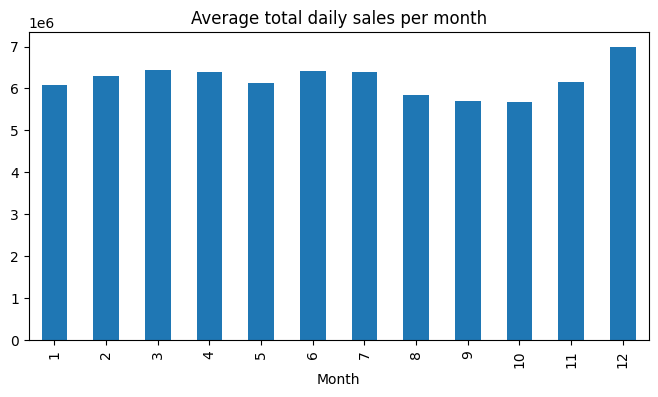

In [48]:
# Graph 7.
daily.groupby(daily["Date"].dt.month)["Sales"].mean().plot(kind="bar", figsize=(8, 4), title="Average total daily sales per month")
plt.xlabel("Month")
plt.show()

December is the highest month (about 7.0 million), August-October the lowest (about 5.7 million). Yearly seasonality exists in total sales as well.

-------------------------------------------------------------------------------------------------------------------------------------
Dekabr ən yüksək ay (təxminən 7,0 mln), avqust-oktyabr ən aşağıdır (təxminən 5,7 mln). İllik mövsümilik ümumi satışda da var.

## Train/Validation

In [49]:
split_date = daily['Date'].max() - pd.Timedelta(days=60)

train_daily = daily[daily['Date'] <= split_date].copy()
val_daily = daily[daily['Date'] > split_date].copy()

print(f"Training data size: {train_daily.shape}")
print(f"Validation data size: {val_daily.shape}")

Training data size: (882, 17)
Validation data size: (60, 17)


To avoid data leakage in time series and ensure the model does not memorize future data, the dataset must be split chronologically instead of randomly. To evaluate the model's true predictive power in accordance with business requirements and medium-term planning, the final 60 days were allocated for validation.

-------------------------------------------------------------------------------------------------------------------------------------
Zaman seriyalarında Data Leakage (məlumat sızması) və modelin gələcəyi əzbərləməsinin qarşısını almaq üçün datanı təsadüfi (random) yox, mütləq zaman ardıcıllığına görə bölməliyik.
Biznes tələblərinə və orta müddətli planlamaya uyğun olaraq, modelin real gücünü yoxlamaq üçün son 60 günü "Ara Sınaq Testi" (Validation) kimi ayırmaq qərarına gəldim.

## Prophet

In [50]:
prophet_train = train_daily[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})
prophet_val = val_daily[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})

In [51]:
from prophet import Prophet
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
prophet_model.fit(prophet_train)

c:\Users\NP\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
23:55:14 - cmdstanpy - INFO - Chain [1] start processing
23:55:20 - cmdstanpy - INFO - Chain [1] done processing


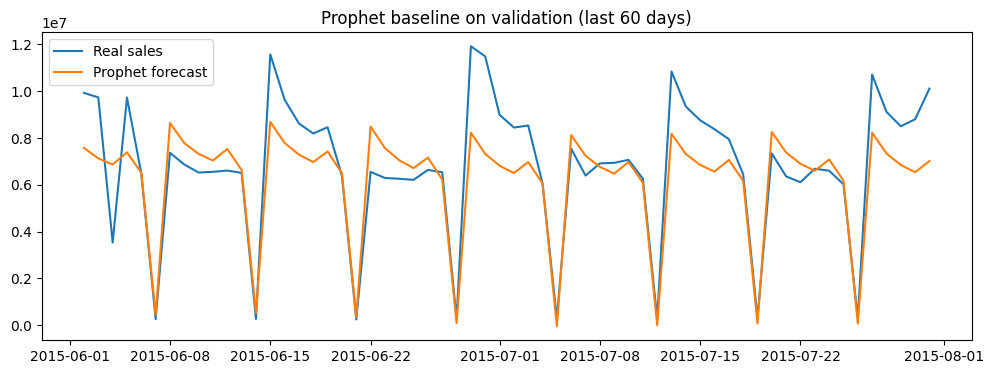

In [52]:
forecast = prophet_model.predict(prophet_val[["ds"]])

prophet_pred = val_daily[["Date", "Sales"]].copy()
prophet_pred["Prophet_Pred"] = forecast["yhat"].values

plt.figure(figsize=(12, 4))
plt.plot(prophet_pred["Date"], prophet_pred["Sales"], label="Real sales")
plt.plot(prophet_pred["Date"], prophet_pred["Prophet_Pred"], label="Prophet forecast")
plt.title("Prophet baseline on validation (last 60 days)")
plt.legend()
plt.show()

Prophet follows the weekly rhythm but misses the Monday peaks (real sales reach 10-12 million, forecast is about 8 million) and does not know about promotions, holidays or how many stores are open. This is the error XGBoost should correct.

-------------------------------------------------------------------------------------------------------------------------------------
Prophet həftəlik ritmi izləyir, amma bazar ertəsi zirvələrini tuta bilmir (real satış 10-12 mln, proqnoz təxminən 8 mln). O, aksiya, bayram və açıq mağaza sayı haqqında heç nə bilmir. XGBoost-un düzəltməli olduğu səhv budur.

In [53]:
prophet_pred.head()

,Date,Sales,Prophet_Pred
882,2015-06-02,9925193,7.574055e+06
883,2015-06-03,9731791,7.127395e+06
884,2015-06-04,3534231,6.865925e+06
885,2015-06-05,9724893,7.385756e+06
886,2015-06-06,6478518,6.517409e+06


## MAE, MAPE, RMSPE Metrics

In [54]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

In [55]:
def rmspe(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    mask = y_true > 0
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    
    percentage_error = (y_true - y_pred) / y_true
    return np.sqrt(np.mean(percentage_error ** 2)) * 100

real_sales_val = prophet_pred['Sales']
prophet_pred_val = prophet_pred['Prophet_Pred']

mae_prophet = mean_absolute_error(real_sales_val, prophet_pred_val)
mape_prophet = mean_absolute_percentage_error(real_sales_val, prophet_pred_val) * 100
rmspe_prophet = rmspe(real_sales_val, prophet_pred_val)

print("Prophet Baseline Metrics:")
print(f"MAE: {mae_prophet:.2f}")
print(f"MAPE: {mape_prophet:.2f}%")
print(f"RMSPE: {rmspe_prophet:.2f}%")

Prophet Baseline Metrics:
MAE: 1180092.98
MAPE: 24.82%
RMSPE: 36.37%


We apply a mask to filter out days where actual sales are greater than 0 within RMSPE (this prevents division by zero error). Next, the validation (test) metrics of the Prophet model are calculated.

Prophet baseline: MAE 1,180,093, MAPE 24.82%, RMSPE 36.37%. This is the number the hybrid has to beat.

-------------------------------------------------------------------------------------------------------------------------------------
RMSPE daxilində real satışın 0-dan böyük olduğu günləri süzmək üçün maska tətbiq edirik (bu, sıfıra bölünmə xətasının qarşısını alır). Ardından, Prophet modelinin validation (test) metrikləri hesablanır.

Prophet baseline: MAE 1 180 093, MAPE 24,82%, RMSPE 36,37%. Hibridin keçməli olduğu rəqəm budur.


## XGBoost Residual Stage

In [56]:
from xgboost import XGBRegressor

# We get Prophet predictions for Train data
forecast_train = prophet_model.predict(prophet_train[['ds']])
train_daily['Prophet_Pred'] = forecast_train['yhat'].values

In [57]:
# We calculate the residuals in the train set
train_daily['Residuals'] = train_daily['Sales'] - train_daily['Prophet_Pred']

In [58]:
# Selecting Features for XGBoost. Extracting the date and target variables

features = [col for col in daily.columns if col not in ['Date', 'Sales']]

X_train = train_daily[features]
y_train_res = train_daily['Residuals']

X_val = val_daily[features]
y_val_res = val_daily['Sales'] - prophet_pred['Prophet_Pred'].values

In [59]:
# We train the XGBoost model on the residuals
xgb_residual_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
xgb_residual_model.fit(X_train, y_train_res)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [60]:
# We take the error predictions for validation and build a hybrid estimate
val_residual_preds = xgb_residual_model.predict(X_val)
hybrid_preds = prophet_pred['Prophet_Pred'].values + val_residual_preds

In [61]:
# We calculate the metrics of the hybrid model
mae_hybrid = mean_absolute_error(real_sales_val, hybrid_preds)
mape_hybrid = mean_absolute_percentage_error(real_sales_val, hybrid_preds) * 100
rmspe_hybrid = rmspe(real_sales_val, hybrid_preds)

We obtain Prophet's in-sample predictions and compute the residuals (Residuals = Actual Sales - Prophet Pred). Since Prophet lacks context regarding external regressors (like Open, Promo, holidays, etc.), we leverage XGBoost to learn these large residual errors. In the validation phase, the final forecast is generated as a hybrid blend: Prophet_Pred + XGBoost_Residual_Pred.

-------------------------------------------------------------------------------------------------------------------------------------
Prophet-in öyrənmə (train) datasındakı proqnozlarını alırıq və qalıqları (Residuals = Real Satış - Prophet Proqnozu) hesablayırıq. Prophet-in xarici faktorlardan (Open, Promo, bayramlar vəs.) xəbəri olmadığı üçün etdiyi böyük səhvləri XGBoost-a öyrədirik. Validation dövründə isə yekun proqnozu Prophet_Pred + XGBoost_Residual_Pred olaraq birləşdiririk.

## Building an End-to-End XGBoost Model

In [62]:
# Adding calendar features to standalone XGBoost
daily_e2e = daily.copy()
daily_e2e['DayOfWeek'] = daily_e2e['Date'].dt.dayofweek
daily_e2e['Month'] = daily_e2e['Date'].dt.month
daily_e2e['Day'] = daily_e2e['Date'].dt.day

# We divide the data again chronologically into train and validation.
train_e2e = daily_e2e[daily_e2e['Date'] <= split_date].copy()
val_e2e = daily_e2e[daily_e2e['Date'] > split_date].copy()

features_e2e = [col for col in daily_e2e.columns if col not in ['Date', 'Sales']]

X_train_e2e = train_e2e[features_e2e]
y_train_e2e = train_e2e['Sales']

X_val_e2e = val_e2e[features_e2e]

In [63]:
# End-to-End XGBoost Model Training and Prediction
xgb_standalone = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
xgb_standalone.fit(X_train_e2e, y_train_e2e)

e2e_preds = xgb_standalone.predict(X_val_e2e)

In [64]:
# Calculation of metrics
mae_e2e = mean_absolute_error(real_sales_val, e2e_preds)
mape_e2e = mean_absolute_percentage_error(real_sales_val, e2e_preds) * 100
rmspe_e2e = rmspe(real_sales_val, e2e_preds)

To benchmark whether Prophet's time-series structure adds any incremental value to the hybrid model, we train a baseline XGBoost model directly targeting actual Sales. For this model, we also include calendar attributes (DayOfWeek, Month, Day) as features.

-------------------------------------------------------------------------------------------------------------------------------------
Prophet-in zaman strukturunun hibrid modelə əlavə dəyər qatıb-qatmadığını yoxlamaq üçün birbaşa real satışları (Sales) hədəf alan müstəqil bir XGBoost modeli qururuq. Bu modeldə əlavə olaraq təqvim xüsusiyyətlərini də (DayOfWeek, Month, Day) feature olaraq daxil edirik.

## Building a Comparison Table

In [65]:
# Creating a comparison table as a pandas DataFrame
metrics_summary = pd.DataFrame({'Model': ['Prophet Alone', 'End-to-End XGBoost', 'Hybrid Model (Prophet + XGB)'],
'MAE': [mae_prophet, mae_e2e, mae_hybrid],'MAPE (%)': [mape_prophet, mape_e2e, mape_hybrid],
'RMSPE (%)': [rmspe_prophet, rmspe_e2e, rmspe_hybrid]})

print("FINAL METRICS COMPARISON TABLE:")
display(metrics_summary)

FINAL METRICS COMPARISON TABLE:


,Model,MAE,MAPE (%),RMSPE (%)
0,Prophet Alone,1.180093e+06,24.822054,36.366567
1,End-to-End XGBoost,4.194220e+05,5.770195,7.586699
2,Hybrid Model (Prophet + XGB),5.099965e+05,16.992579,32.108975


In [66]:
# Calculating the percentage improvement of the hybrid model compared to other models
print("\nMathematical Improvement Indicators of the Hybrid Model:")
imp_vs_prophet = ((rmspe_prophet - rmspe_hybrid) / rmspe_prophet) * 100
imp_vs_xgb = ((rmspe_e2e - rmspe_hybrid) / rmspe_e2e) * 100

print(f"- RMSPE error reduction compared to Prophet: {imp_vs_prophet:.2f}%")
print(f"- RMSPE error reduction compared to End-to-End XGBoost: {imp_vs_xgb:.2f}%")


Mathematical Improvement Indicators of the Hybrid Model:
- RMSPE error reduction compared to Prophet: 11.71%
- RMSPE error reduction compared to End-to-End XGBoost: -323.23%


The hybrid reduces the error of Prophet alone (MAE -56.8%, MAPE -31.5%, RMSPE -11.7%) but is clearly worse than end-to-end XGBoost (RMSPE 32.11% vs 7.59%). In this setup the added complexity is not justified by the numbers.

-------------------------------------------------------------------------------------------------------------------------------------
Hibrid təkbaşına Prophet-in xətasını azaldır (MAE -56,8%, MAPE -31,5%, RMSPE -11,7%), amma end-to-end XGBoost-dan açıq-aydın pisdir (RMSPE 32,11% qarşı 7,59%). Bu qurulumda əlavə mürəkkəblik rəqəmlərlə özünü doğrultmur.

## Error analysis

In [67]:
check = prophet_pred[["Date", "Sales"]].copy()
check["Prophet"] = prophet_pred["Prophet_Pred"].values
check["Hybrid"] = hybrid_preds
check["E2E"] = e2e_preds
check["Sunday"] = check["Date"].dt.dayofweek == 6

for name in ["Prophet", "Hybrid", "E2E"]:
    ape = ((check["Sales"] - check[name]) / check["Sales"]).abs() * 100
    print(name, "| Sunday MAPE:", round(ape[check["Sunday"]].mean(), 1),"| Other days MAPE:", round(ape[~check["Sunday"]].mean(), 1))

Prophet | Sunday MAPE: 80.0 | Other days MAPE: 16.3
Hybrid | Sunday MAPE: 81.9 | Other days MAPE: 7.0
E2E | Sunday MAPE: 5.2 | Other days MAPE: 5.9


Further error analysis shows that on Sundays (8 of the 60 validation days) Prophet has 80.0% MAPE and the hybrid 81.9%, while end-to-end XGBoost has 5.2%. On the other days the hybrid reduces Prophet's MAPE from 16.3% to 7.0%, compared with 5.9% for end-to-end XGBoost. Why the hybrid does not correct Sundays although it receives "Open" was not investigated.

-------------------------------------------------------------------------------------------------------------------------------------
Əlavə xəta analizi göstərir ki, bazar günlərində (validation-ın 60 gündən 8-i) Prophet 80,0%, hibrid 81,9% MAPE verir, end-to-end XGBoost isə 5,2%. Digər günlərdə hibrid Prophet-in MAPE-sini 16,3%-dən 7,0%-ə endirir, end-to-end XGBoost-da bu rəqəm 5,9%-dir. Hibridin "Open" feature-ni aldığı halda bazar günlərini niyə düzəltmədiyi araşdırılmayıb.